# Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import seaborn as sns
import pickle
import copy

import torch
from torch import nn, Tensor

import time
import joblib

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [19]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import fm.pretraining_flat as preTrain
import fm.lossPlots as lossPlots
import fm.training as training

In [20]:
PROJECT_ROOT = os.path.abspath("..")
PROJECT_ROOT

'/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching'

In [4]:
# for the plots :
import mplhep as hep

plt.style.use(hep.style.CMS)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,

    "lines.linewidth": 2,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",

    "legend.frameon": False,
})

# Upload the Pre-processed DataFrames

In [5]:
df_VBF = pd.read_pickle("df_VBF.pkl")

# Pre-Training

## Define the Context and the Target

In [6]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt", 
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 

]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_significance","MET_sumEt"
]

train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols
)

y_cols = ["tau1_corr", "tau2_corr"]

## Pre-Train

In [7]:
# sanity check:
missing = [c for c in (train_cols + y_cols) if c not in df_VBF.columns]
print("Missing:", missing[:10], "..." if len(missing) > 10 else "")
assert len(missing) == 0

Missing: [] 


In [8]:
preTraining_flat_MSE = preTrain.pretrain_flat(
    df_VBF,
    train_cols=train_cols,
    y_cols=y_cols,
    out_prepared=os.path.join(PROJECT_ROOT, "results", "prepared_splits", "flat"),
    out_runs=os.path.join(PROJECT_ROOT, "results", "runs_prepared", "flat"),
    loss_type="mse",
)


PRETRAIN FLAT | mode=X_GLOBAL__Y_GLOBAL
prepared: /Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/flat/X_GLOBAL__Y_GLOBAL
save_dir:  /Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/runs_prepared/flat/X_GLOBAL__Y_GLOBAL
[ep    1] train=1.949060  val=1.919925  best=1.919925  bad=0/30
[ep   10] train=1.446550  val=1.433953  best=1.430327  bad=1/30
[ep   20] train=1.283570  val=1.281329  best=1.281329  bad=0/30
[ep   30] train=1.230729  val=1.230713  best=1.206020  bad=8/30
[ep   40] train=1.169148  val=1.146423  best=1.138273  bad=9/30
[ep   50] train=1.148004  val=1.151211  best=1.122938  bad=3/30
[ep   60] train=1.137282  val=1.172567  best=1.101382  bad=8/30
[ep   70] train=1.128145  val=1.105577  best=1.095318  bad=6/30
[ep   80] train=1.111921  val=1.103558  best=1.087981  bad=3/30
[ep   90] train=1.105273  val=1.114170  best=1.061895  bad=2/30
[ep  100] train=1.094337  val=1.107314  best=1.061895  bad=12/30

In [9]:
preTraining_flat_HUBER = preTrain.pretrain_flat(
    df_VBF,
    train_cols=train_cols,
    y_cols=y_cols,
    out_prepared=os.path.join(PROJECT_ROOT, "results", "prepared_splits", "flat"),
    out_runs=os.path.join(PROJECT_ROOT, "results", "runs_prepared", "flat", "HUBER_d1"),
    loss_type="huber",
    huber_delta=1.0,
)


PRETRAIN FLAT | mode=X_GLOBAL__Y_GLOBAL
prepared: /Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/prepared_splits/flat/X_GLOBAL__Y_GLOBAL
save_dir:  /Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/results/runs_prepared/flat/HUBER_d1/X_GLOBAL__Y_GLOBAL
[ep    1] train=0.682004  val=0.689027  best=0.689027  bad=0/30
[ep   10] train=0.543672  val=0.533709  best=0.533709  bad=0/30
[ep   20] train=0.494653  val=0.499799  best=0.487270  bad=2/30
[ep   30] train=0.475508  val=0.481874  best=0.471786  bad=5/30
[ep   40] train=0.460087  val=0.454513  best=0.454326  bad=8/30
[ep   50] train=0.458187  val=0.444690  best=0.444690  bad=0/30
[ep   60] train=0.451770  val=0.452051  best=0.438474  bad=3/30
[ep   70] train=0.447593  val=0.451621  best=0.437937  bad=4/30
[ep   80] train=0.446430  val=0.438681  best=0.436187  bad=8/30
[ep   90] train=0.441656  val=0.446738  best=0.436187  bad=18/30
[ep  100] train=0.438027  val=0.435994  best=0.429455 

# Loss Plots

In [13]:
# Carico i risultati :
RUNS_FLAT_MSE   = os.path.join(PROJECT_ROOT, "results", "runs_prepared", "flat")
RUNS_FLAT_HUBER = os.path.join(PROJECT_ROOT, "results", "runs_prepared", "flat", "HUBER_d1")

MODES = ["X_GLOBAL__Y_GLOBAL", "X_NONE__Y_NONE"] 

def load_results_dict(base_dir, modes, device="cpu"):
    out = {}
    for mode in modes:
        run_dir = os.path.join(base_dir, mode)
        if not os.path.exists(run_dir):
            print(f"[skip] missing: {run_dir}")
            continue
        out[mode] = training.load_run(run_dir, device=device)
    return out

res_flat_mse   = load_results_dict(RUNS_FLAT_MSE, MODES, device="cpu")
res_flat_huber = load_results_dict(RUNS_FLAT_HUBER, MODES, device="cpu")

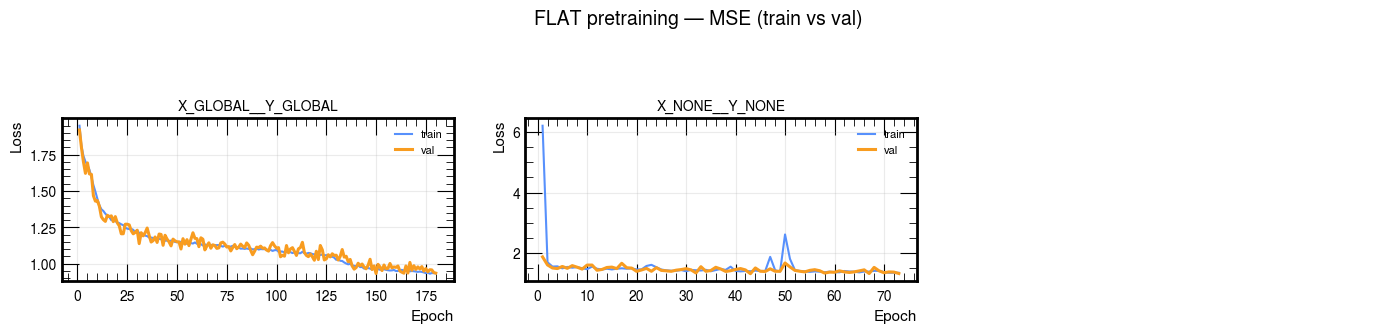

In [14]:
# MSE:
lossPlots.plot_loss_grid(
    res_flat_mse,
    title="FLAT pretraining — MSE (train vs val)",
    order=MODES,
    logy=False,
)

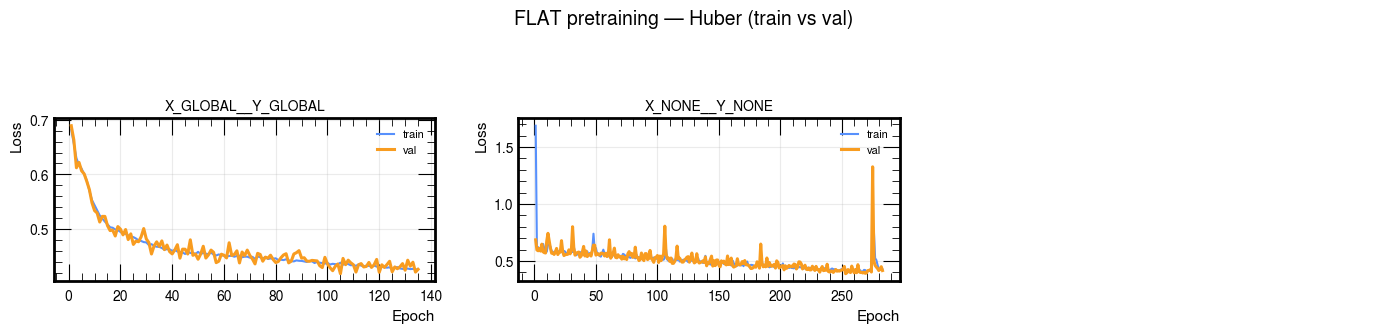

In [15]:
# Huber:
lossPlots.plot_loss_grid(
    res_flat_huber,
    title="FLAT pretraining — Huber (train vs val)",
    order=MODES,
    logy=False,
)

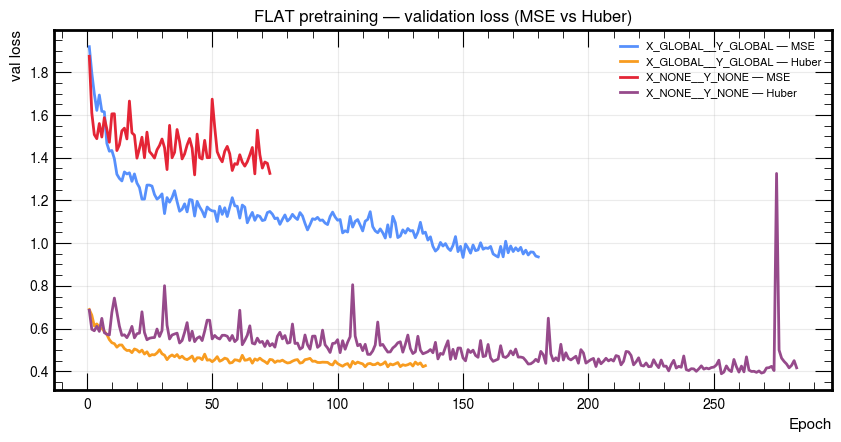

In [16]:
res_compare = {}

for mode in MODES:
    if mode in res_flat_mse:
        res_compare[f"{mode} — MSE"] = res_flat_mse[mode]
    if mode in res_flat_huber:
        res_compare[f"{mode} — Huber"] = res_flat_huber[mode]

lossPlots.plot_loss_overlay(
    res_compare,
    title="FLAT pretraining — validation loss (MSE vs Huber)",
    which="val",
    logy=False,
    legend_loc="upper right",
)